In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
mouse = "cfm002mjr"
date = 240514
rec = 'meas00'

denoised_path = "N:/GEVI_Wave/Analysis/Visual/" + mouse + "/20" + str(date) + "/" + rec + '/cG_unmixed_dFF_denoised.h5'

with h5py.File(denoised_path, 'r') as mov_file:
    mov = mov_file['mov'][:10000]

In [25]:
def plot_movie_stats(mov, title=None):
    """
    mov: numpy array with shape (t, y, x)
    Computes mean, median, std over time for each pixel
    and plots them as three images.
    """
    # Check shape
    if mov.ndim != 3:
        raise ValueError("mov must have shape (t, y, x)")

    # Collapse over time axis (axis 0)
    mean_img = mov.mean(axis=0)
    median_img = np.median(mov, axis=0)
    std_img = mov.std(axis=0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    im0 = axes[0].imshow(mean_img, aspect="auto")
    axes[0].set_title("Mean over time")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(median_img, aspect="auto")
    axes[1].set_title("Median over time")
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(std_img, aspect="auto")
    axes[2].set_title("Std over time")
    fig.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

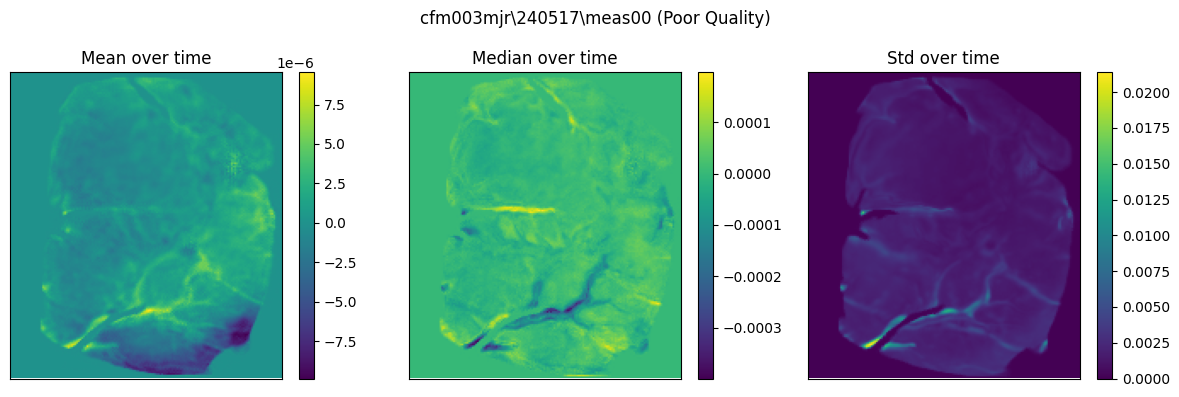

In [26]:
plot_movie_stats(mov, f'{mouse}\\{date}\\{rec} (Poor Quality)')